# Calculation general CME distributions for a fast rotation star. 

## the interesting quantity now is the dopplershift in the direction of the observer

The velocity component of the CME in direction of the observer, 
$$ v \cos \beta = v (\cos \theta \cos \theta' + \sin \theta\sin \theta' \cos \phi') $$
will now be supplemented by a component comming from the rotation of the star itself, namely 
$$\omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta,$$
where $\omega (\alpha)$ is the angular frequency at lattitude $\alpha$ and $R$ is the radius of the star, which we assume to be constant. 
For a rigid rotator $\omega (\alpha) = \omega$, for the solar case this has been observed to obey some relation of the form $\omega (\alpha) = A + B \sin^2 + C \sin^4$. The assumption that the fast rotator is a perfect sphere can be corrected by taking $R(\alpha)$ insteand where the radius can vary with lattitude. 

In order for this correction to be significant, the order of magnitude of $\omega R$ should be on the order of the velocity of a CME $v$. In the solar case, this correction will be neglegtible. 

To solve for the distribution in dopplershift $d$ in direction of the observer, we solve following integral
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

import dependencies

In [18]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [19]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

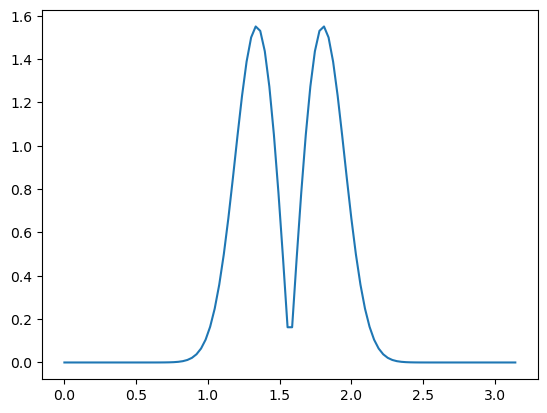

In [20]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$
For a proper description we refer to the associated paper.



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. We here under properly normalize the distribution!

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

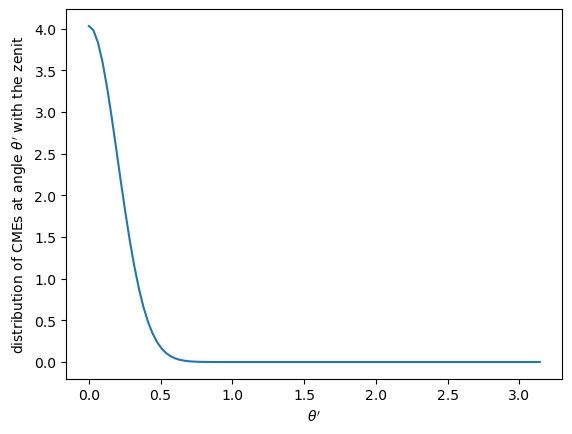

In [21]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

so we use $d = v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) + \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta$, or equivalently that
$\cos \phi' = \frac{d- v\cos\theta'\cos\theta - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta}{v\sin \theta'\sin\theta}$
to find that 

# Check this again! seems reversed! (in the old ones)

\begin{equation}
    \int d\phi'   \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta) = \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',d)}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 

\begin{equation}
    \rho_d(d) = \frac{1}{N} \int \sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi))  \sin\theta' d\theta'  \rho^{CME}(\theta') \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',d)}.
\end{equation}
Hence, 
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int  d\theta d\phi  d\theta'  \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta') \frac{1}{\sin\phi'(\theta, \theta',d)}.
\end{equation}


# intergral numerical

## rigid rotator satisfying 
$$\omega R = v$$

In [22]:
import time
from scipy.integrate import nquad
omega = 1
v = 1
R = 1

# general distribution for given tau
def get_sinphi2(cosphi2):
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_cosphi2(theta, phi, theta2, dop, tau):
    # \frac{d- v\cos\theta'\cos\theta - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta}{v\sin \theta'\sin\theta}
    return (dop - v * np.cos(theta) * np.cos(theta2) - omega * R * np.sin(tau) * np.sin(phi) * np.sin(theta))/ (v * np.sin(theta) * np.sin(theta2)) 

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(dop, tau):
    def integrand2(theta, phi, theta2):
        return integrand(theta, phi, theta2, dop, tau)
    return integrand2

def integrand(theta, phi, theta2, dop, tau):
    cosphi2 = get_cosphi2(theta, phi, theta2, dop, tau)
    sinphi2 = get_sinphi2(cosphi2)
    alpha = get_alpha(tau, theta, phi)
    return    np.where(np.abs(cosphi2) >1, 0,  
            np.sin(theta) * rho(alpha) * np.sin(theta2) * rho_CME(theta2) / (sinphi2 + 0.001) )


def get_rho_dop(dop, tau):
    start_time = time.time()
    print(dop, tau, end='\r')
    result, error = nquad(f_integrand_(dop, tau), [[0, np.pi],       # theta, phi, theta2
                                                [0, 2*np.pi],         # phi
                                                [0, np.pi / 2 ]], opts={"epsrel":0.05, 'epsabs':2e-2})       # theta2
    end_time = time.time()
    print(f'For params {dop=}, {tau = } we find the distibution to be {result }, with estimated error {error}. \
        Taking {(end_time-start_time):.2f} to calculate.')

    return result


def rho_dops(dops, tau):
    return np.array([get_rho_dop(dop, tau) for dop in dops])

dops = np.linspace(-2,2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)


def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_dops(dops, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"incoming velocity in units of  [$v$]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return np.array(dens)






In [23]:
from pathlib import Path

def get_or_create_data(name):
    filename = f'calculations/{name}_rotation.npy'
    file_path = Path(filename)

    
    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")


        # --- FIX STARTS HERE ---
        # Create the 'calculations' directory if it doesn't exist
        # parents=True: creates any missing parent folders
        # exist_ok=True: doesn't crash if the folder already exists
        file_path.parent.mkdir(parents=True, exist_ok=True)
        # -----------------------

        # Replace this with your actual data generation logic
        data = run_taus(Taus)
        
        # Save the file so it exists next time
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")
        
    return data

dens = get_or_create_data("sundist")


File 'calculations/sundist_rotation.npy' found.


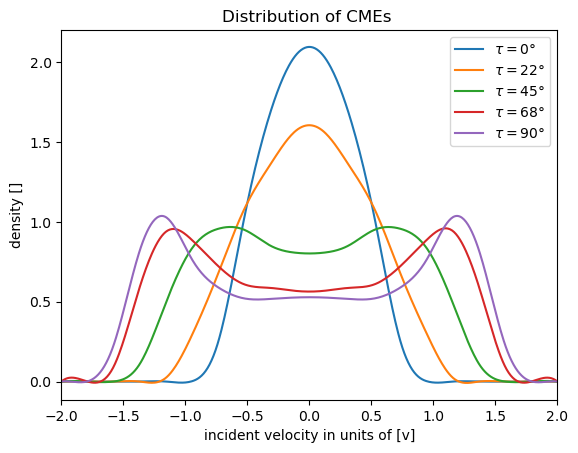

In [24]:

x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(-2,2)
    # plt.ylim(0,1)
    plt.show()


plotting_(dens, Taus)



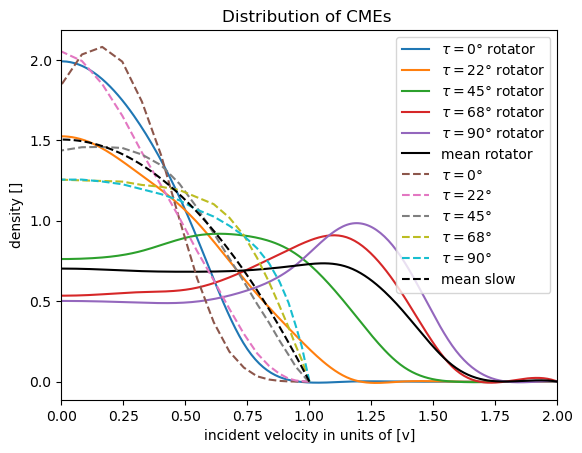

In [35]:
dens_nonrot = np.load('../calculations/sundist.npy')

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)


x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


def plotting_compare(dens, dens_nonrot, taus):
    mean_rot= np.zeros(500)
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        normalisatie = np.sum((smooth_curve[:-1] + smooth_curve[1:])/2 * (x[1:] - x[:-1])) / 2
        plt.plot(x, smooth_curve / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
        mean_rot += smooth_curve / normalisatie * np.sin(taus[i])
    plt.plot(x, mean_rot / np.sum(np.sin(taus)),  "-", color='black', label="mean rotator")
       
    for i,d in enumerate(dens_nonrot):
        # ind = np.argsort(np.cos(betas))
        # x2 = np.cos(betas)[ind]
        # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
        # smooth_curve = make_interp_spline(x2, d2)(x)
        # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
        plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
    y = np.linspace(0,np.pi, 300)
    plt.plot(np.cos(y), 2*np.sin(y)**2 / (np.average(np.sin(y) * np.sin(y)**2) * np.pi), "--", color='black', label="mean slow ")
    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_compare(dens, dens_nonrot, Taus)



numerical (not yet enough accruracy)
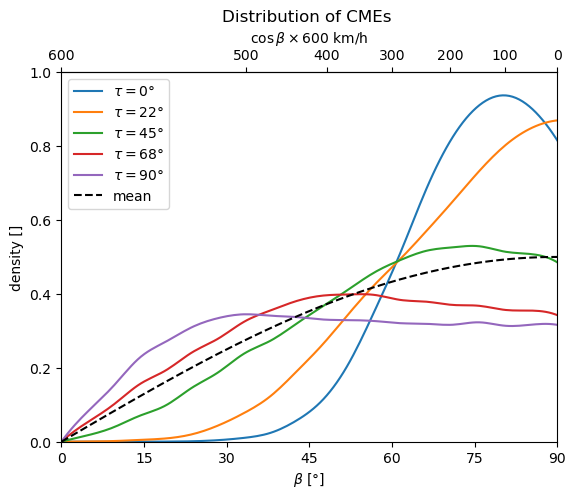

Monte carlo (with sin at 0)
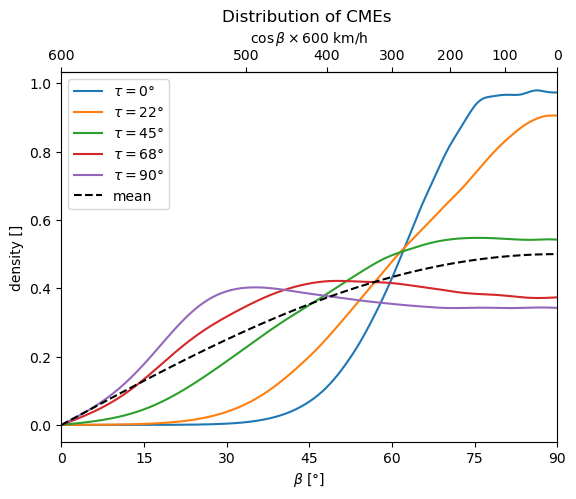


# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

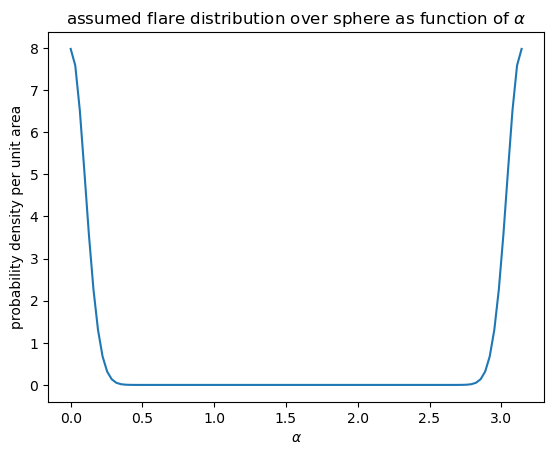

In [36]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [37]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (0.9993158136231646, 3.647190528409362e-12)
0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)
0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)
1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)
1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


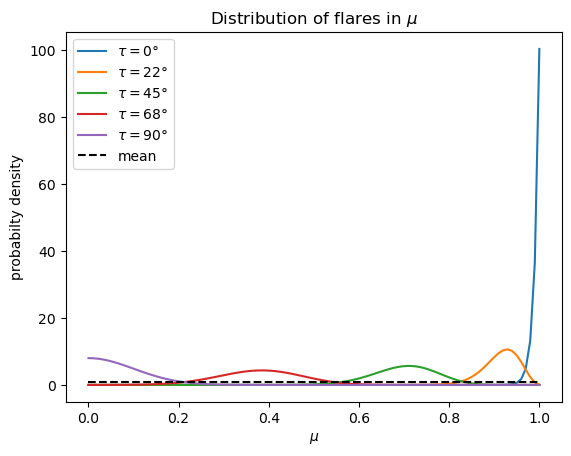

File 'calculations/polardist_rotation.npy' found.


In [38]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dops = np.linspace(0,1.3, 40)
dens = get_or_create_data("polardist")


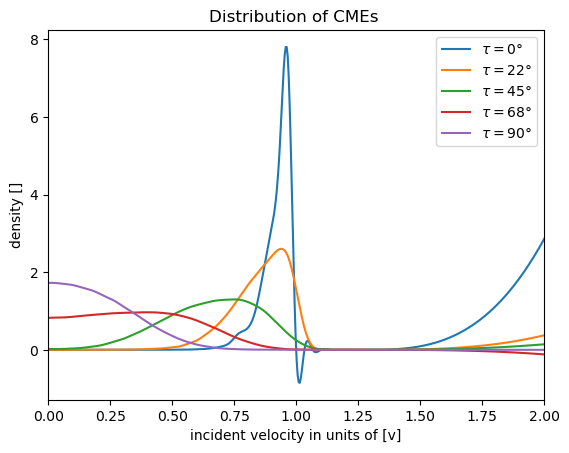

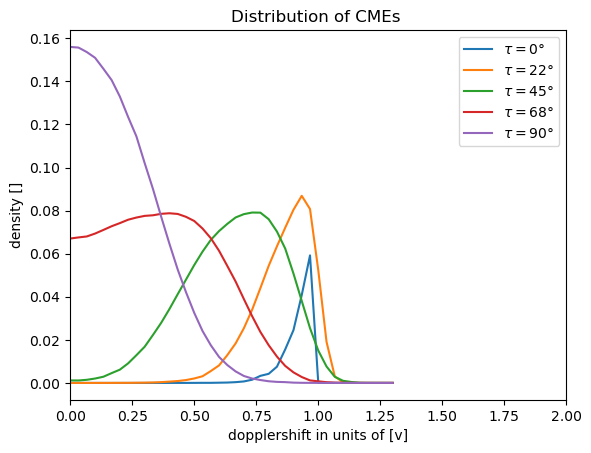

In [39]:

def plotting_2(dens, taus):
    for i,d in enumerate(dens):
        # smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(dops, d, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    # plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    # ax = plt.gca()
    # secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    # secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel("dopplershift in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0, 2)
    # plt.ylim(0,1)
    plt.show()


x = np.linspace(0,2, 500)



def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_(dens, Taus)
plotting_2(dens, Taus)


# conclusion: don't smooth things as they are too singular around 1


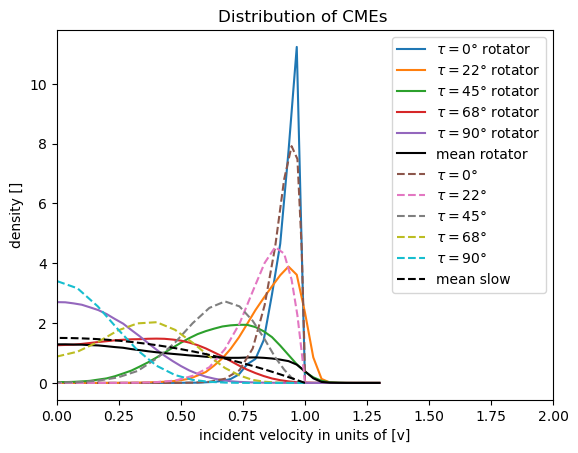

In [43]:
dens_nonrot = np.load('../calculations/polardist.npy')

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)


x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


# def plotting_compare(dens, dens_nonrot, taus):
#     for i,d in enumerate(dens):
#         normalisatie = np.sum((d[:-1] + d[1:])/2 * (dops[1:] - dops[:-1])) 
#         plt.plot(dops, d / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
       
#     for i,d in enumerate(dens_nonrot):
#         # ind = np.argsort(np.cos(betas))
#         # x2 = np.cos(betas)[ind]
#         # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
#         # smooth_curve = make_interp_spline(x2, d2)(x)
#         # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
#         plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
#     plt.legend()
#     plt.title("Distribution of CMEs ")
#     plt.xlabel(r"incident velocity in units of [v]")
#     plt.ylabel(r"density []")
#     plt.xlim(0,2)
#     # plt.ylim(0,1)
#     plt.show()


def plotting_compare(dens, dens_nonrot, taus):
    mean_rot= np.zeros(40)
    for i,d in enumerate(dens):
        normalisatie = np.sum((d[:-1] + d[1:])/2 * (dops[1:] - dops[:-1])) 
        plt.plot(dops, d / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
        mean_rot += d / normalisatie * np.sin(taus[i])
    plt.plot(dops, mean_rot / np.sum(np.sin(taus)),  "-", color='black', label="mean rotator")
       
    for i,d in enumerate(dens_nonrot):
        # ind = np.argsort(np.cos(betas))
        # x2 = np.cos(betas)[ind]
        # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
        # smooth_curve = make_interp_spline(x2, d2)(x)
        # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
        plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
    y = np.linspace(0,np.pi, 300)
    plt.plot(np.cos(y), 2*np.sin(y)**2 / (np.average(np.sin(y) * np.sin(y)**2) * np.pi), "--", color='black', label="mean slow ")
    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_compare(dens, dens_nonrot, Taus)

old with only 20 points:

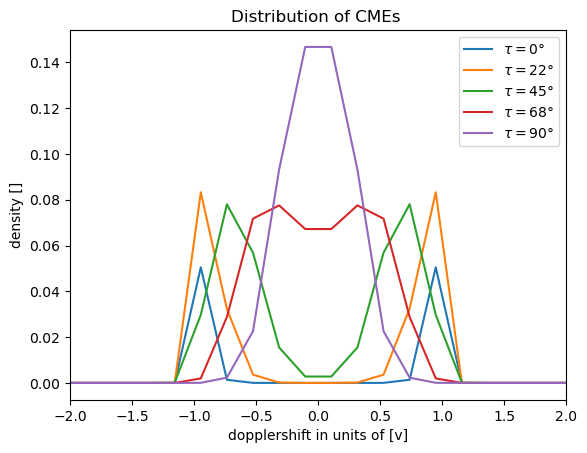
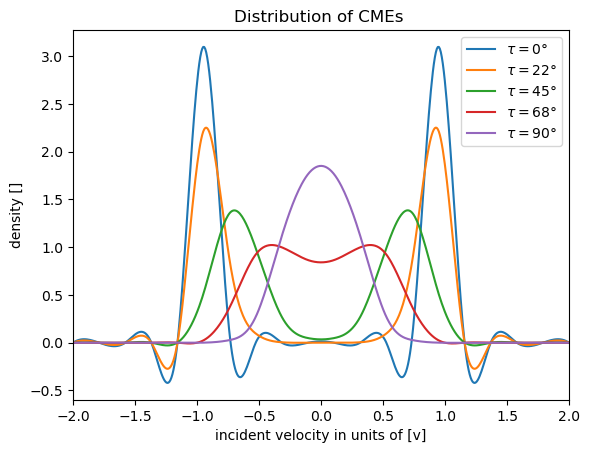

# Uniform distribution

0.9999999999999999


Text(0, 0.5, 'probability density per unit area')

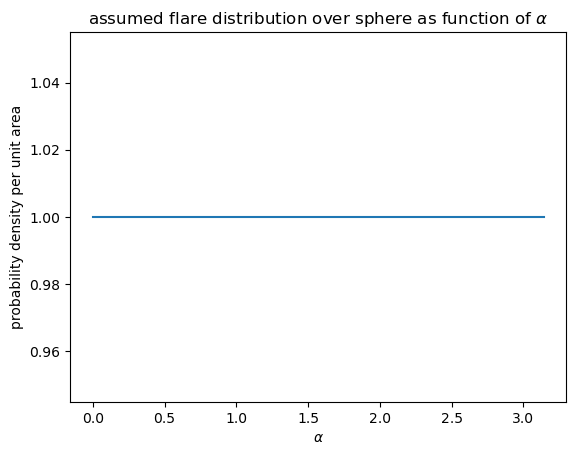

In [93]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return alpha * 0 + 1 /N

N = quad(lambda a :  rho(a) * np.sin(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [94]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (12.566370614359176, 1.395147399203453e-13)
0.39269908169872414 (12.566370614359176, 1.395147399203453e-13)
0.7853981633974483 (12.566370614359176, 1.395147399203453e-13)
1.1780972450961724 (12.566370614359176, 1.395147399203453e-13)
1.5707963267948966 (12.566370614359176, 1.395147399203453e-13)


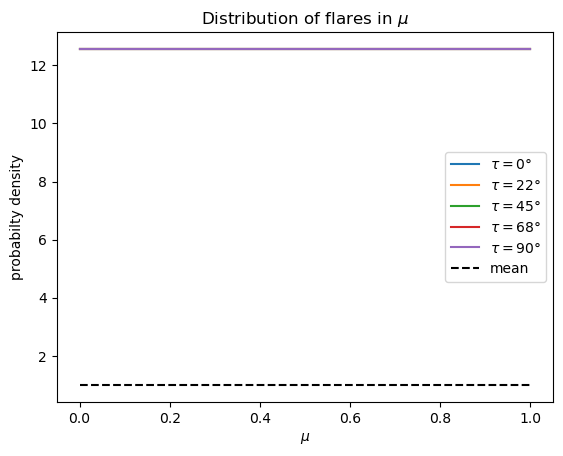

File 'calculations/uniformdist_rotation.npy' found.


In [ ]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dops = np.linspace(0,1.8, 40)
dens = get_or_create_data("uniformdist")


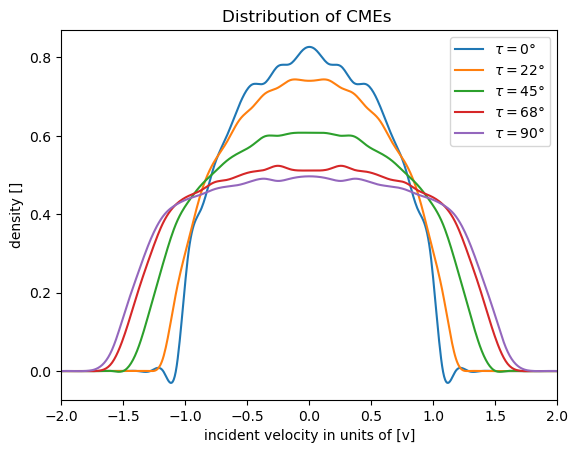

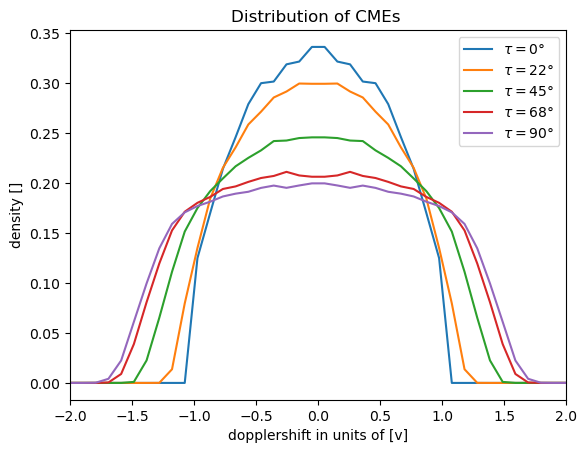

In [96]:
# def speed2beta(v):
#     return np.arccos(v / 600 )

# def beta2speed(beta):
#     return  np.cos(beta) * 600

# from scipy.interpolate import make_interp_spline


def plotting_2(dens, taus):
    for i,d in enumerate(dens):
        # smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(dops, d, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    # plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    # ax = plt.gca()
    # secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    # secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel("dopplershift in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(-2, 2)
    # plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)
plotting_2(dens, Taus)

